In [1]:
# Imports
import sys
import os
import json
import argparse
import numpy as np
# Ensure src/utils is importable regardless of working directory.
# Notebooks don't define __file__, so fall back to cwd (VS Code/Jupyter
# run notebooks with cwd set to the notebook's own directory).
try:
    _here = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _here = os.getcwd()
sys.path.insert(0, os.path.join(_here, '..', 'utils'))
import fit_utils

In [2]:
import matplotlib.pyplot as plt
import uproot

In [3]:
def parse_args():
    """Parse command line arguments."""
    parser = argparse.ArgumentParser(description="Dalitz plot from ROOT tree.")
    parser.add_argument("input", help="Input ROOT file")
    parser.add_argument(
        "--type", dest="plot_type", choices=["dalitz", "phsp"], default="dalitz",
        help="Plot type: 'dalitz' -> dalitz_dalitz.png, 'phsp' -> dalitz-phsp.png"
    )
    return parser.parse_args()

In [4]:
def invariant_mass2(px1, py1, pz1, e1, px2, py2, pz2, e2):
    """Compute M^2 of the sum of two 4-vectors."""
    e  = e1  + e2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    return e**2 - px**2 - py**2 - pz**2

In [5]:
# Manually define args, since argparse doesn't work in jupyter notebooks.
infile = "../../ntuple/lhcb/eta2mumugamma/20260608/combined_files.root"
outdir = "../../out/eta2mumugamma/turbo/20260608/"
results_filename = "dalitz_fit_results.json"
fit_plot_filename = "dalitz_fit_plot.png"

In [6]:
def get_arrays(infile, branch_names):
    """Get arrays from branches."""
    # Process ROOT file
    with uproot.open(infile) as f:
        tree = f["tree"]
        return tree.arrays(branch_names, library="np")

# Extract branches
branches = get_arrays(infile, ["prt_pid", "prt_px", "prt_py", "prt_pz", "prt_e", "tag_dtf_chi2", "tag_dtf_m"])
# Unzip branches into separate variables
pids = branches["prt_pid"]
pxs = branches["prt_px"]
pys = branches["prt_py"]
pzs = branches["prt_pz"]
es = branches["prt_e"]
tag_dtf_chi2 = branches["tag_dtf_chi2"]
tag_dtf_m = branches["tag_dtf_m"]

In [ ]:
print(f"pids: {pids}")
n = 0
for pid in pids:
    if len(pid) > 3: n += 1

print(f"{n} / {len(pids)} have >1 candidate")

pids: [array([-13.,  13.,  22.]) array([-13.,  13.,  22.])
 array([-13.,  13.,  22.]) ... array([-13.,  13.,  22., -13.,  13.,  22.])
 array([-13.,  13.,  22.]) array([-13.,  13.,  22.])]
1273604 / 3711492


In [ ]:
def compute_candidate(pids, pxs, pys, pzs, es, ms, metrics=None, min=True):
    """Find the best candidate in one event; return its (m12, m23, mass).
    Selects the candidate with best metrics (smallest for min=True).
    Returns (None, None, None) if no candidate is found.
    """
    valid_daughters, valid_indices = [], []
    # Look over candidates in one event.
    for j in range(len(ms)):
        p1 = p2 = p3 = None  # gamma, mu+, mu-
        # Loop over daughters in one candidate.
        for k in range(3):
            idx = j * 3 + k
            pid = pids[idx]
            px = pxs[idx] / 1000.
            py = pys[idx] / 1000.
            pz = pzs[idx] / 1000.
            e = es[idx] / 1000.
            if pid == 22: p1 = (px, py, pz, e)
            elif pid == -13: p2 = (px, py, pz, e)
            elif pid == 13: p3 = (px, py, pz, e)
        # If all three daughters are found, add to valid candidates.
        if None not in (p1, p2, p3):
            valid_daughters.append((p1, p2, p3))
            valid_indices.append(j)

    # If no valid candidates, return None.
    if not valid_indices: return None, None, None

    # Filter metric values to only include valid candidates.
    valid_metrics = [metrics[k] for k in valid_indices]
    # Find the best candidate based on metrics.
    # filtered_idx is the index of the best candidate in valid_daughters, but
    # it could be different from the index in ms, which is why we need to map it
    # back to the original list of candidates. This is why we're not calling it
    # "best_idx" here.
    best_candidate, filtered_idx = fit_utils.find_best_candidate(
        valid_daughters, metrics=valid_metrics, min=min)
    # Get the index of the best candidate in the original list of candidates.
    # This is necessary because malformed candidates are filtered out, so the
    # index in valid_daughters may not match the index in ms unless we map it
    # back to the original list.
    best_idx = valid_indices[filtered_idx]

    # Compute invariant masses for the best candidate.
    p1, p2, p3 = best_candidate
    m12 = invariant_mass2(*p1, *p2)   # m^2(gamma, mu+)
    m23 = invariant_mass2(*p2, *p3)   # m^2(mu+, mu-)
    return m12, m23, ms[best_idx]


def compute_dalitz_and_mass(pids, pxs, pys, pzs, es, ms, metrics):
    """Compute (m12, m23, mass) for the best candidate in every event.
    Returns three arrays: m12s, m23s, best_masses.
    """
    m12s, m23s, best_masses = [], [], []
    for i in range(len(pids)):
        # Compute the best candidate for this event.
        m12, m23, mass = compute_candidate(pids[i], pxs[i], pys[i], pzs[i], es[i],
                                            ms[i], metrics[i])
        # Append to list of valid best candidates if results are valid (not
        # None) and positive.
        if None not in (m12, m23, mass) and m12 > 0 and m23 > 0:
            m12s.append(m12)
            m23s.append(m23)
            best_masses.append(mass)
    # Return as numpy arrays for easier plotting and analysis.
    return np.array(m12s), np.array(m23s), np.array(best_masses)

In [16]:
m12s, m23s, masses = compute_dalitz_and_mass(pids, pxs, pys, pzs, es, tag_dtf_m, tag_dtf_chi2)

Best candidate: ((np.float64(-0.37077933454410167), np.float64(-0.41173056395241103), np.float64(5.226512629639621), np.float64(5.2558)), (np.float64(0.18063170056290764), np.float64(-1.7203539804621801), np.float64(23.823031029513434), np.float64(23.885983688214544)), (np.float64(-0.07939708794095805), np.float64(-0.7909198023269939), np.float64(12.380608190986159), np.float64(12.406549919343053)))
filtered_idx: 0
ms[filtered_idx]: 1092.881780653749
Best candidate index in original list: 0
ms[best_k]: 1092.881780653749
Best candidate: ((np.float64(-0.674288923034297), np.float64(0.2333385041203015), np.float64(12.428254794184424), np.float64(12.44872)), (np.float64(-0.5935401691234521), np.float64(0.5457285431063849), np.float64(15.509005043115305), np.float64(15.530309420409212)), (np.float64(-1.2099333107423889), np.float64(1.0017205386981967), np.float64(28.675890322713713), np.float64(28.719074360876444)))
filtered_idx: 0
ms[filtered_idx]: 565.1812575815067
Best candidate index in

In [10]:
# Check ranges and shapes. m12/m23 ranges should match what we saw before
# this refactor (m12: [0.0119, 0.9969], m23: [0.0447, 1.1849]) -- if they
# don't, something about the candidate selection changed behavior.
print(f"--- Dalitz Plot Statistics ---")
print(f"m12 range: [{m12s.min():.4f}, {m12s.max():.4f}]")
print(f"m23 range: [{m23s.min():.4f}, {m23s.max():.4f}]")
print(f"mass range: [{masses.min():.4f}, {masses.max():.4f}]")

# Shape check -- m12s/m23s/masses are now guaranteed the same length by
# construction (compute_dalitz_and_mass appends all three together under
# one condition), so this just confirms that, rather than hoping two
# separately-filtered arrays happened to end up the same length.
print(f"--- Shape check --- ")
print(f"m12s shape: {m12s.shape}")
print(f"m23s shape: {m23s.shape}")
print(f"masses shape: {masses.shape}")

--- Dalitz Plot Statistics ---
m12 range: [0.0119, 0.9969]
m23 range: [0.0447, 1.1849]
mass range: [-5036176.3352, 4647.4329]
--- Shape check --- 
m12s shape: (3711492,)
m23s shape: (3711492,)
masses shape: (3711492,)


Text(0, 0.5, '$m_{23}^2$ [GeV$^2$]')

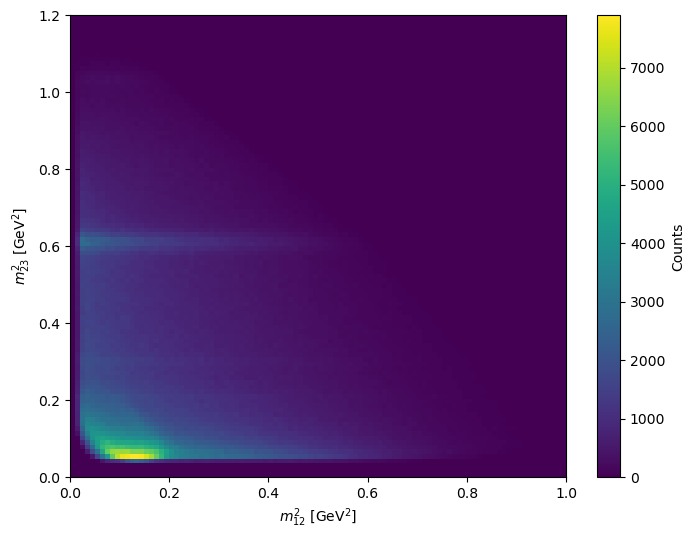

In [11]:
# Test implementation with a quick plot of the Dalitz distribution
plt.figure(figsize=(8, 6))
plt.hist2d(m12s, m23s, bins=100, cmap='viridis', range=[[0, 1.0], [0, 1.2]])
plt.colorbar(label='Counts')
plt.xlabel(r'$m_{12}^2$ [GeV$^2$]')
plt.ylabel(r'$m_{23}^2$ [GeV$^2$]')

Text(0, 0.5, '$m_{23}^2$ [GeV$^2$]')

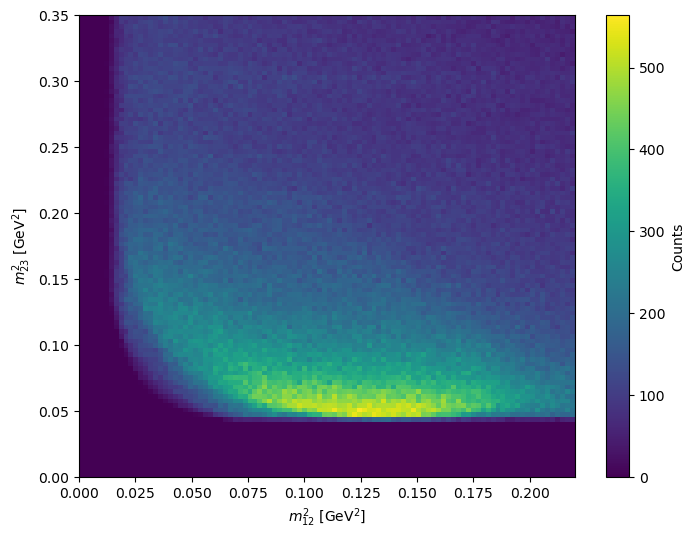

In [12]:
# Test implementation with a quick plot of the Dalitz distribution in physical range
plt.figure(figsize=(8, 6))
plt.hist2d(m12s, m23s, bins=100, cmap='viridis', range=[[0, 0.22], [0, 0.35]])
plt.colorbar(label='Counts')
plt.xlabel(r'$m_{12}^2$ [GeV$^2$]')
plt.ylabel(r'$m_{23}^2$ [GeV$^2$]')

In [13]:
def fit_gauss(infile, xmin=400.0, xmax=696.0, nbins=80,
              mean_init=547.9, sigma_init=10.0):
    """Run the gaussian fit and return the fitted mean and sigma."""
    # Get mass histogram (counts, bin_edges).
    centers, counts, errors = fit_utils.load_histogram(infile=infile, xmin=xmin,
                                                 xmax=xmax, nbins=nbins)
    bin_edges = np.linspace(xmin, xmax, nbins + 1) 
    N = counts.sum()
    print(f"[info] {int(N)} entries in [{xmin}, {xmax}] MeV across {nbins} bins",
          file=sys.stderr)
    # Pass these into fit_utils.make_gauss_cost
    cost = fit_utils.make_gauss_cost(counts, bin_edges, xmin, xmax)
    # Define initial vals and limits for parameters
    init = dict(
        mean = mean_init,
        sigma = sigma_init,
        n_sig = N * 0.5,
        n_bkg = N * 0.5,
        c0 = 0.0,
        c1 = 0.0,
    )
    limits = dict(
        mean = (xmin, xmax),
        sigma = (1.0, 50.0),
        n_sig = (0.0, N * 2),
        n_bkg = (0.0, N * 2),
        c0 = (-1.0, 1.0),
        c1 = (-1.0, 1.0)
    )
    # Run fit
    m = fit_utils.run_fit(cost, init, limits)
    p, e = m.values, m.errors
    print(f"[fit] valid={m.valid}  "
          f"mean={p['mean']:.3f}±{e['mean']:.3f} MeV  "
          f"σ={p['sigma']:.3f}±{e['sigma']:.3f} MeV",
          file=sys.stderr)

    # Return fitted mean/sigma
    return p['mean'], p['sigma'], e['mean'], e['sigma']

In [14]:
def plot_dalitz():
    pass